# Phase 2: Exploratory Data Analysis & Data Quality
This notebook transition our workflow into Python-based exploratory data analysis. We combine patients, visits, and billing datasets, analyze missing values and outliers, perform distribution analysis across key dimensions, and engineer leakage-controlled features for machine learning.

### Import Dependencies and Connect to MySQL

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from sqlalchemy import create_engine
from dotenv import load_dotenv

# Add parent directory to path so we can import build_features
sys.path.append("..")
import build_features

# Load connection settings
load_dotenv(dotenv_path="../.env")

host = os.getenv("MYSQL_HOST", "localhost")
port = os.getenv("MYSQL_PORT", "3306")
user = os.getenv("MYSQL_USER", "root")
password = os.getenv("MYSQL_PASSWORD", "")
db = os.getenv("MYSQL_DATABASE", "hospital_db")

import urllib.parse
password_encoded = urllib.parse.quote_plus(password)
conn_str = f"mysql+pymysql://{user}:{password_encoded}@{host}:{port}/{db}"
engine = create_engine(conn_str)

# Load dataset
df = build_features.load_joined_data(engine)
print(f"Master joined dataframe loaded. Shape: {df.shape}")

Matplotlib is building the font cache; this may take a moment.


Master joined dataframe loaded. Shape: (25000, 20)


### 1. Missing Value Analysis
We profile missing values in detail, focusing particularly on `approved_amount`, `payment_days`, and `length_of_stay_hours`.

In [2]:
missing_counts = df.isnull().sum()
missing_pcts = (df.isnull().sum() * 100 / len(df)).round(2)
missing_summary = pd.DataFrame({
    'Missing Count': missing_counts,
    'Percentage (%)': missing_pcts
})
print("--- Missing Value Summary across all columns ---")
print(missing_summary[missing_summary['Missing Count'] > 0])

--- Missing Value Summary across all columns ---
                 Missing Count  Percentage (%)
approved_amount           1318            5.27
payment_days               790            3.16


#### Business Rationale for Missing Values:
1. **`approved_amount`**: Claims that have a status of `'Pending'` or `'Rejected'` will not have an approved amount, resulting in `NULL` values. If a claim is `'Rejected'`, the approved amount is effectively $0.00. For `'Pending'` claims, the approval decision has not yet been made.
2. **`payment_days`**: This tracks the time elapsed between billing and receiving payment. For `'Pending'` or `'Rejected'` claims, payment has not been received, meaning `payment_days` remains empty/missing.
3. **`length_of_stay_hours`**: Any missing values in this clinical metric could be due to OPD visits where length of stay is negligible and not recorded, or data entry omissions during patient discharge.

### 2. Distribution Analysis
We analyze the distribution of visits across key categorical dimensions: `department`, `visit_type`, `insurance_provider`, and `city`.

C:\Users\yuvar\AppData\Local\Temp\ipykernel_12448\1986038799.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='department', data=df, ax=axes[0, 0], order=df['department'].value_counts().index, palette='viridis')
C:\Users\yuvar\AppData\Local\Temp\ipykernel_12448\1986038799.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='visit_type', data=df, ax=axes[0, 1], order=df['visit_type'].value_counts().index, palette='coolwarm')


C:\Users\yuvar\AppData\Local\Temp\ipykernel_12448\1986038799.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='insurance_provider', data=df, ax=axes[1, 0], order=df['insurance_provider'].value_counts().index, palette='magma')
C:\Users\yuvar\AppData\Local\Temp\ipykernel_12448\1986038799.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='city', data=df, ax=axes[1, 1], order=df['city'].value_counts().index, palette='rocket')


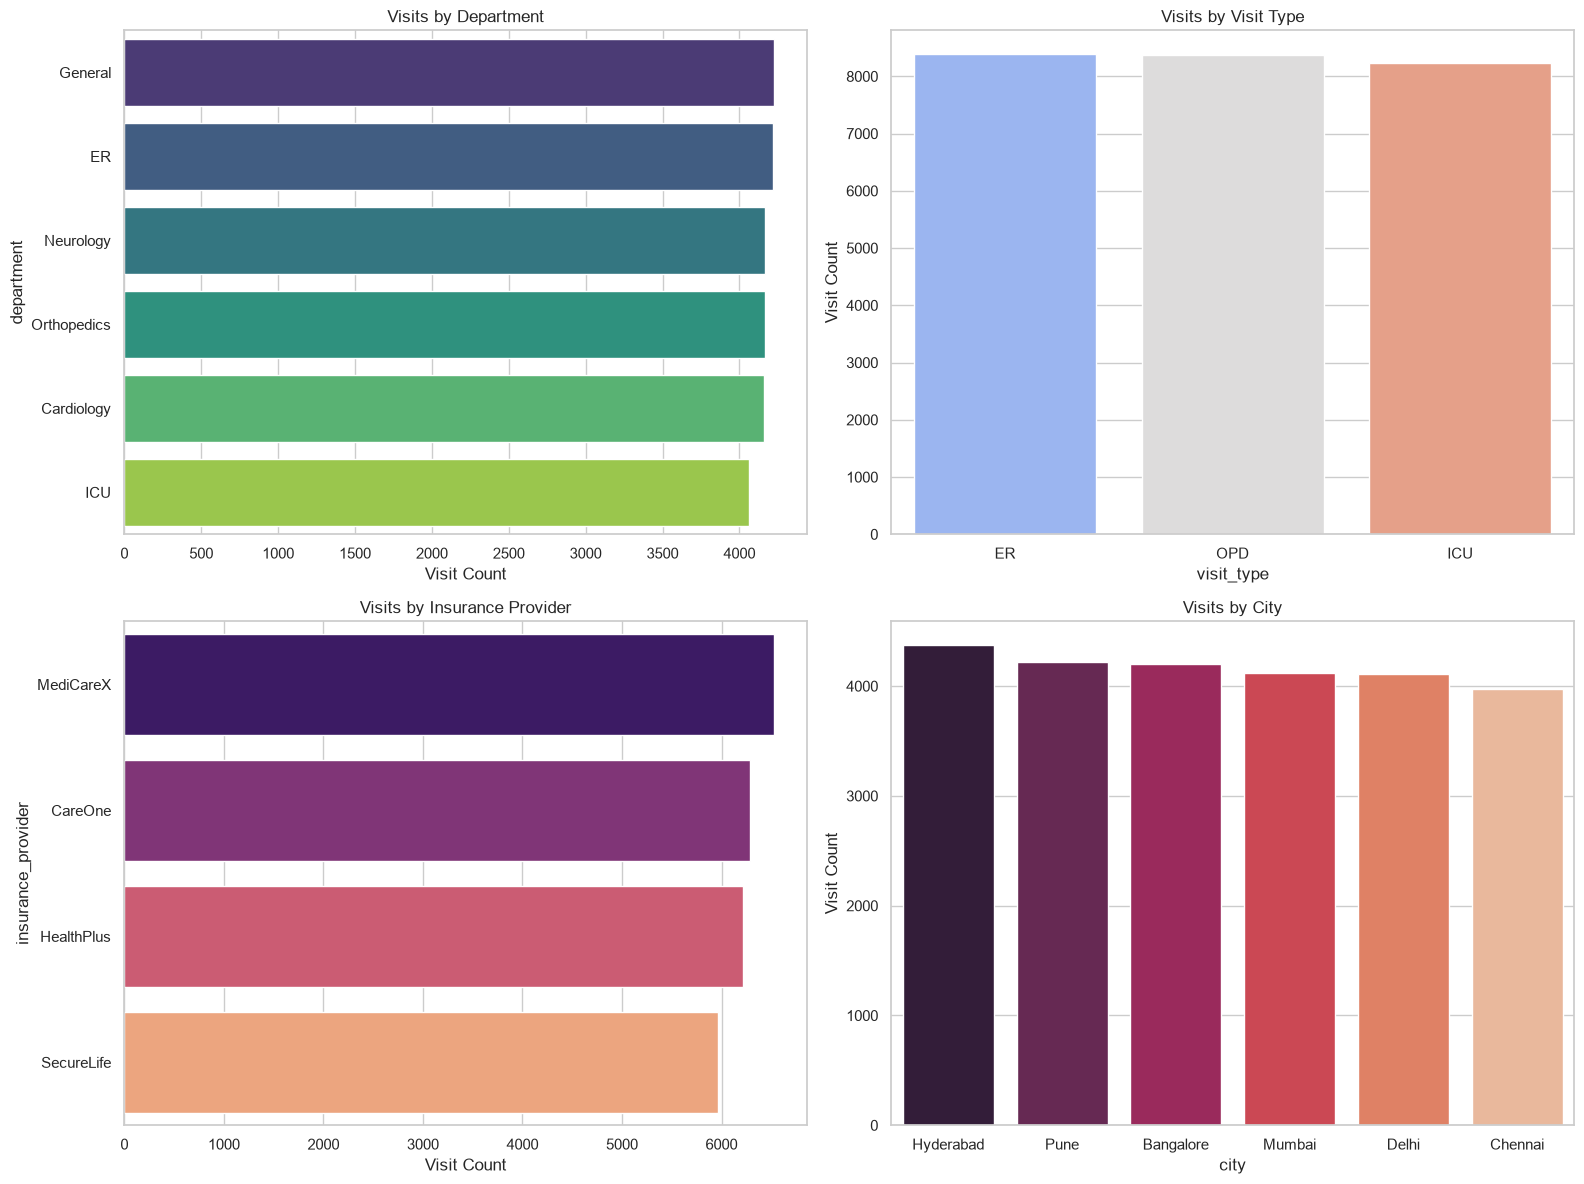

In [3]:
# Setup plotting directory
os.makedirs("../plots", exist_ok=True)
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Department
sns.countplot(y='department', data=df, ax=axes[0, 0], order=df['department'].value_counts().index, palette='viridis')
axes[0, 0].set_title('Visits by Department')
axes[0, 0].set_xlabel('Visit Count')

# Visit Type
sns.countplot(x='visit_type', data=df, ax=axes[0, 1], order=df['visit_type'].value_counts().index, palette='coolwarm')
axes[0, 1].set_title('Visits by Visit Type')
axes[0, 1].set_ylabel('Visit Count')

# Insurance Provider
sns.countplot(y='insurance_provider', data=df, ax=axes[1, 0], order=df['insurance_provider'].value_counts().index, palette='magma')
axes[1, 0].set_title('Visits by Insurance Provider')
axes[1, 0].set_xlabel('Visit Count')

# City
sns.countplot(x='city', data=df, ax=axes[1, 1], order=df['city'].value_counts().index, palette='rocket')
axes[1, 1].set_title('Visits by City')
axes[1, 1].set_ylabel('Visit Count')

plt.tight_layout()
plt.savefig("../plots/categorical_distributions.png", dpi=300)
plt.show()

### 3. Outlier Detection and Analysis
We use the Interquartile Range (IQR) method to detect outliers in numerical columns: `billed_amount`, `payment_days`, and `length_of_stay_hours`.

In [4]:
def detect_outliers_iqr(series):
    series_clean = series.dropna()
    q1 = series_clean.quantile(0.25)
    q3 = series_clean.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = series_clean[(series_clean < lower_bound) | (series_clean > upper_bound)]
    return len(outliers), lower_bound, upper_bound

for col in ['billed_amount', 'payment_days', 'length_of_stay_hours']:
    count, low, high = detect_outliers_iqr(df[col])
    total_non_null = df[col].notnull().sum()
    pct = (count * 100 / total_non_null).round(2) if total_non_null > 0 else 0
    print(f"{col}: {count} outliers found out of {total_non_null} non-null values ({pct}%). Lower Bound={low:.2f}, Upper Bound={high:.2f}")

billed_amount: 373 outliers found out of 25000 non-null values (1.49%). Lower Bound=-13640.97, Upper Bound=53621.49
payment_days: 509 outliers found out of 24210 non-null values (2.1%). Lower Bound=-5.50, Upper Bound=30.50
length_of_stay_hours: 256 outliers found out of 25000 non-null values (1.02%). Lower Bound=-16.07, Upper Bound=53.34


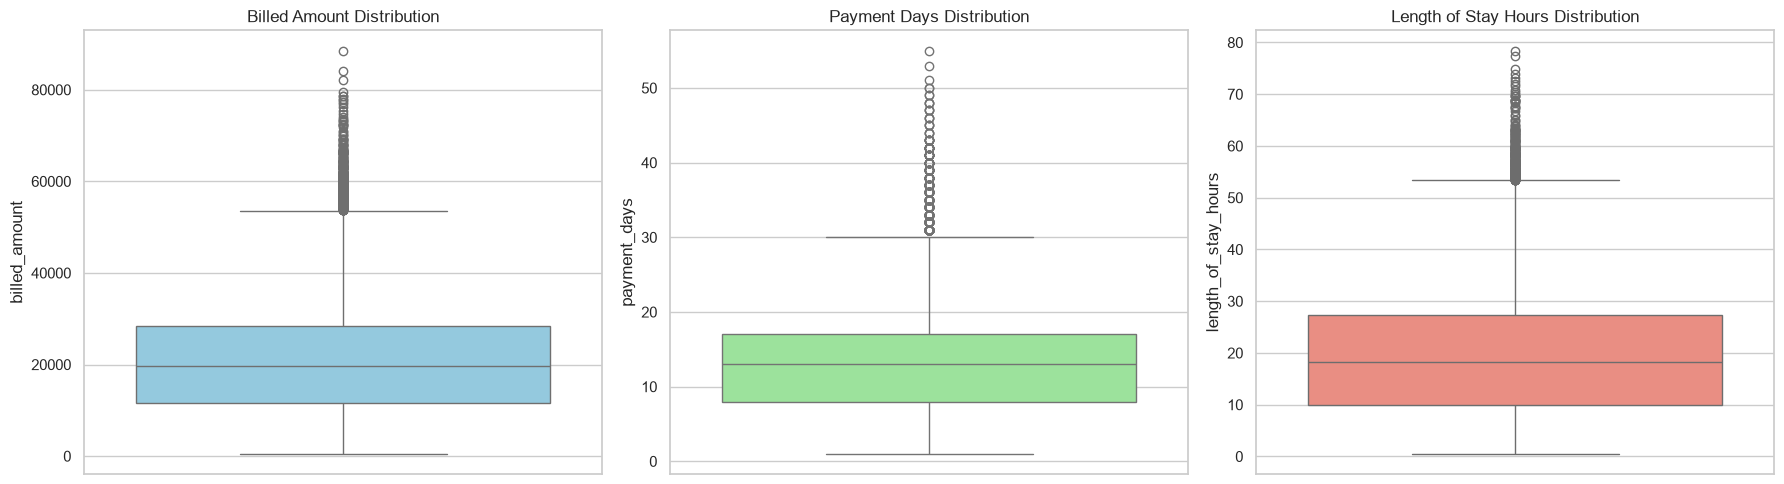

In [5]:
# Plot boxplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(y='billed_amount', data=df, ax=axes[0], color='skyblue')
axes[0].set_title('Billed Amount Distribution')

sns.boxplot(y='payment_days', data=df, ax=axes[1], color='lightgreen')
axes[1].set_title('Payment Days Distribution')

sns.boxplot(y='length_of_stay_hours', data=df, ax=axes[2], color='salmon')
axes[2].set_title('Length of Stay Hours Distribution')

plt.tight_layout()
plt.savefig("../plots/numerical_boxplots.png", dpi=300)
plt.show()

#### Outlier Treatment Strategy:
- **`billed_amount`**: Large bills are expected for complex medical encounters (e.g. ICU, surgeries). They represent valid clinical risk profiles, so we preserve them rather than deleting them. In modeling, we can apply robust scaling or log-transformation to reduce the influence of extreme values.
- **`length_of_stay_hours`**: Patients with extended stays are outliers compared to standard OPD/ER encounters, but represent actual high-acuity operational bottlenecks. We should preserve them to retain clinical prediction details.

### 4. Feature Engineering (Leakage-Controlled)
To prevent data leakage, we execute a time-based split (sorting by `visit_date` and dividing into 80% train and 20% test). We fit aggregates (e.g. insurance provider rejection rates, department realization ratios) only on the training set, and map them to both train and test partitions. This strictly mimics a production setup.

In [6]:
# Sort by visit date
df = df.sort_values('visit_date').reset_index(drop=True)

# Compute split index
split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

print(f"Split dataset into Train: {train_df.shape[0]} rows (up to {train_df['visit_date'].max().date()}) and Test: {test_df.shape[0]} rows (from {test_df['visit_date'].min().date()})")

# Fit aggregates on train
aggregates = build_features.fit_feature_aggregates(train_df)
print("Computed training aggregates (leakage-controlled):")
print("Global Rejection Rate:", round(aggregates['global_rejection'], 4))
print("Global Department Realization Rate:", round(aggregates['global_realization'], 4))

# Transform both partitions using the aggregates
train_features = build_features.transform_features(train_df, aggregates)
test_features = build_features.transform_features(test_df, aggregates)

# Recombine into a single table for exporting (keeping track of train/test partition for Phase 3)
train_features['split'] = 'train'
test_features['split'] = 'test'
model_df = pd.concat([train_features, test_features], axis=0).reset_index(drop=True)

print(f"Final model table columns: {model_df.columns.tolist()}")

Split dataset into Train: 20000 rows (up to 2025-11-08) and Test: 5000 rows (from 2025-11-08)
Computed training aggregates (leakage-controlled):
Global Rejection Rate: 0.1533
Global Department Realization Rate: 0.7412
Final model table columns: ['visit_id', 'patient_id', 'visit_date', 'department', 'visit_type', 'length_of_stay_hours', 'risk_score', 'doctor_id', 'age', 'gender', 'city', 'insurance_provider', 'chronic_flag', 'registration_date', 'bill_id', 'billed_amount', 'approved_amount', 'claim_status', 'payment_days', 'billing_date', 'days_since_registration', 'visit_month', 'visit_day_of_week', 'visit_frequency', 'avg_length_of_stay_patient', 'provider_rejection_rate', 'revenue_realization_rate_dept', 'split']


### 5. Exporting Dataset and Feature Schema
We create the output directory, save the compiled dataset to `data_outputs/model_table.csv`, and export the JSON schema detailing each feature's business role and datatype.

In [7]:
os.makedirs("../data_outputs", exist_ok=True)

# Export CSV
model_df.to_csv("../data_outputs/model_table.csv", index=False)
print("Saved modeling dataset to 'data_outputs/model_table.csv'!")

# Define feature schema
schema = {
    "features": [
        {"name": "age", "type": "numeric", "description": "Age of the patient (clinical risk factor)"},
        {"name": "gender", "type": "categorical", "description": "Demographic gender identifier"},
        {"name": "city", "type": "categorical", "description": "Geographic city location of the patient"},
        {"name": "chronic_flag", "type": "binary", "description": "Indicator if patient has chronic condition"},
        {"name": "length_of_stay_hours", "type": "numeric", "description": "Duration of stay in hours"},
        {"name": "department", "type": "categorical", "description": "Clinical department treated in"},
        {"name": "visit_type", "type": "categorical", "description": "Visit type (OPD, ER, ICU)"},
        {"name": "days_since_registration", "type": "numeric", "description": "Days between registration and encounter date"},
        {"name": "visit_month", "type": "numeric", "description": "Month of the visit (seasonal operational patterns)"},
        {"name": "visit_day_of_week", "type": "numeric", "description": "Day of week of the visit (weekday workload patterns)"},
        {"name": "visit_frequency", "type": "numeric", "description": "Total visits by patient (historical volume risk)"},
        {"name": "avg_length_of_stay_patient", "type": "numeric", "description": "Average length of stay for the patient (clinical complexity)"},
        {"name": "provider_rejection_rate", "type": "numeric", "description": "Leakage-controlled historical rejection rate of insurance provider"},
        {"name": "revenue_realization_rate_dept", "type": "numeric", "description": "Leakage-controlled department-level revenue realization ratio"}
    ],
    "targets": [
        {"name": "risk_score", "type": "categorical", "description": "Clinical and operational risk score (Low, Medium, High)"},
        {"name": "claim_status", "type": "categorical", "description": "Financial claim outcome (Paid, Pending, Rejected)"}
    ],
    "metadata": [
        {"name": "visit_id", "type": "key"},
        {"name": "patient_id", "type": "key"},
        {"name": "split", "type": "metadata", "description": "train or test marker"}
    ]
}

# Export JSON
with open("../data_outputs/feature_schema.json", "w", encoding="utf-8") as f:
    json.dump(schema, f, indent=2)
print("Saved feature schema to 'data_outputs/feature_schema.json'!")

Saved modeling dataset to 'data_outputs/model_table.csv'!
Saved feature schema to 'data_outputs/feature_schema.json'!
